In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

In [ ]:
iris = load_iris()

# Convert it into a DataFrame so it's easier to work with
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("=" * 55)
print("        PROJECT 2: DATA CLASSIFICATION USING AI")
print("=" * 55)

# Let's take a quick look at the data
print("\n[1] First 5 rows of the dataset:")
print(df.head())

print("\n[2] Dataset Shape (rows, columns):", df.shape)

print("\n[3] Basic Statistics:")
print(df.describe().round(2))

print("\n[4] Class Distribution (balanced = good!):")
print(df['species_name'].value_counts())

        PROJECT 2: DATA CLASSIFICATION USING AI

[1] First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

[2] Dataset Shape (rows, columns): (150, 6)

[3] Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83


[5] After StandardScaler — Mean of each feature (should be ~0):
[-0. -0. -0. -0.]

[6] Training samples : 120
    Testing  samples  : 30


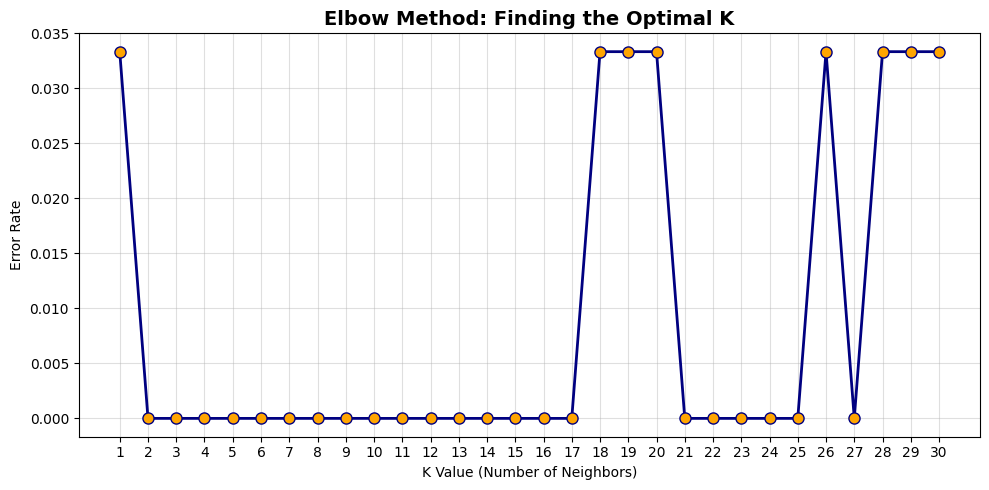


[7] Elbow curve saved as 'elbow_curve.png'

    Chosen K = 5 (based on elbow curve analysis)

[8] Model trained successfully with KNN (k=5)!


In [ ]:
X = iris.data     # The 4 measurements: sepal length, sepal width, petal length, petal width
y = iris.target   # The class: 0=Setosa, 1=Versicolor, 2=Virginica

# --- Step 3: Feature Scaling (The Gatekeeper Rule) ---
# KNN uses distance to classify points. If one feature has
# values like 0-1000 and another is 0-1, the larger scale
# will dominate. StandardScaler fixes this by making
# mean = 0 and variance = 1 for every feature.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n[5] After StandardScaler — Mean of each feature (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 4))

# --- Step 4: Train-Test Split (80% train, 20% test) ---
# We shuffle the data first to remove any ordering bias
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 20% goes to testing (held back / locked)
    random_state=42,     # Seed for reproducibility
    shuffle=True         # Randomize before splitting
)

print(f"\n[6] Training samples : {len(X_train)}")
print(f"    Testing  samples  : {len(X_test)}")

# --- Step 5: Find the Best K using the Elbow Method ---
# We try different values of K and pick the one with
# the lowest error rate (the "elbow" point on the graph)

error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    predictions_temp = knn_temp.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, predictions_temp))

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, color='navy', marker='o',
         markerfacecolor='orange', markersize=8, linewidth=2)
plt.title('Elbow Method: Finding the Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("\n[7] Elbow curve saved as 'elbow_curve.png'")

# Based on the elbow curve, K=5 is a solid default choice
# for Iris — low error, not overfitting, not underfitting
best_k = 5
print(f"\n    Chosen K = {best_k} (based on elbow curve analysis)")

# --- Step 6: Train the KNN Model ---
# INSTANTIATE — build the model frame
model = KNeighborsClassifier(n_neighbors=best_k)

# FIT — let the model memorize the training data pattern
model.fit(X_train, y_train)

print("\n[8] Model trained successfully with KNN (k=5)!")


In [ ]:
predictions = model.predict(X_test)

# --- Step 8: Accuracy Score ---
accuracy = accuracy_score(y_test, predictions)
print(f"\n[9] Accuracy Score : {accuracy * 100:.2f}%")


[9] Accuracy Score : 100.00%


In [ ]:
# Accuracy alone can be misleading on imbalanced data.
# F1 Score = harmonic mean of Precision and Recall.
# It gives a balanced measure of model quality.
f1 = f1_score(y_test, predictions, average='weighted')
print(f"    F1 Score       : {f1:.4f}")

    F1 Score       : 1.0000


In [ ]:
print("\n[10] Classification Report:")
print("-" * 50)
target_names = ['Setosa', 'Versicolor', 'Virginica']
print(classification_report(y_test, predictions, target_names=target_names))


[10] Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



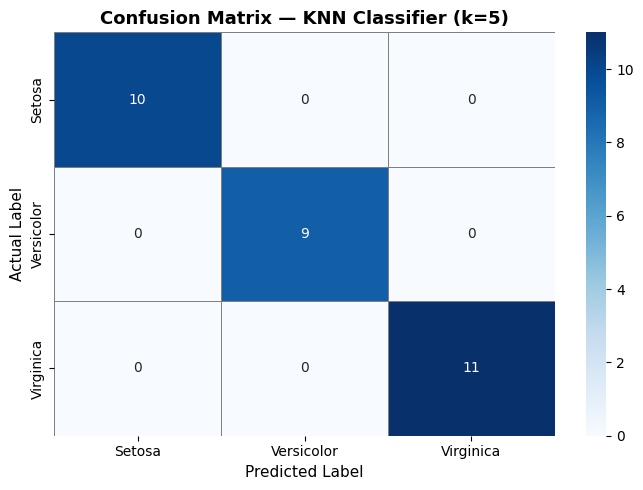

[11] Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — KNN Classifier (k=5)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("[11] Confusion matrix saved as 'confusion_matrix.png'")

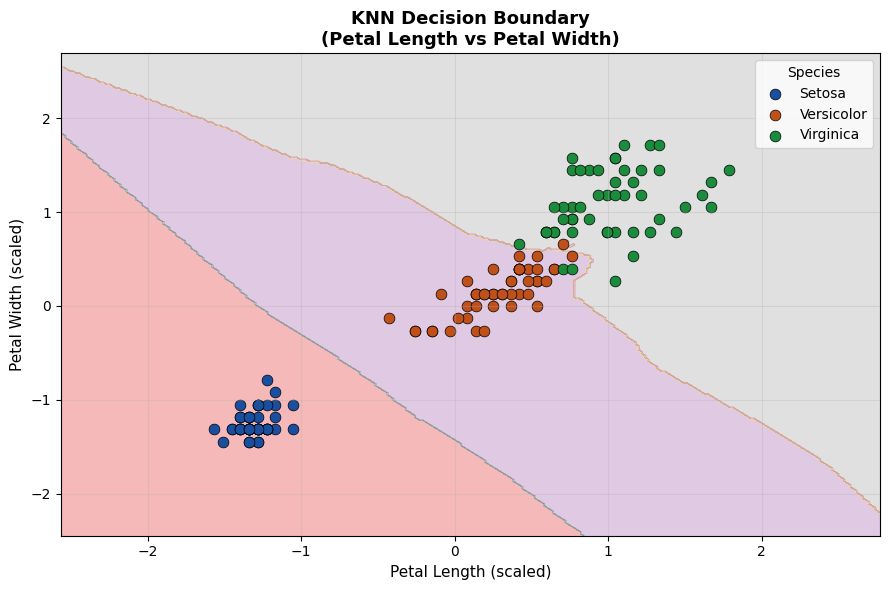

[12] Decision boundary plot saved as 'decision_boundary.png'


In [ ]:
# We use Petal Length vs Petal Width since they are the most
# informative features for separating the three classes.

plt.figure(figsize=(9, 6))

# Create a mesh grid to color the decision regions
x_min, x_max = X_scaled[:, 2].min() - 1, X_scaled[:, 2].max() + 1
y_min, y_max = X_scaled[:, 3].min() - 1, X_scaled[:, 3].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Train a 2D version of the model just for visualization
model_2d = KNeighborsClassifier(n_neighbors=best_k)
model_2d.fit(X_train[:, 2:4], y_train)
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

colors_bg = ['#aec6f0', '#f0c4a8', '#a8f0b4']
colors_pt = ['#1a4fa0', '#c0501a', '#1a8c3c']

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

for i, (label, color) in enumerate(zip(target_names, colors_pt)):
    idx = np.where(y == i)
    plt.scatter(X_scaled[idx, 2], X_scaled[idx, 3],
                label=label, color=color, edgecolors='k',
                s=60, linewidth=0.5)

plt.title('KNN Decision Boundary\n(Petal Length vs Petal Width)', fontsize=13, fontweight='bold')
plt.xlabel('Petal Length (scaled)', fontsize=11)
plt.ylabel('Petal Width (scaled)', fontsize=11)
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150)
plt.show()
print("[12] Decision boundary plot saved as 'decision_boundary.png'")


In [ ]:
print("\n" + "=" * 55)
print("        BONUS: Predicting a New Flower Sample")
print("=" * 55)

# Let's say we found a new iris flower with these measurements:
# Sepal Length=5.1, Sepal Width=3.5, Petal Length=1.4, Petal Width=0.2
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# We MUST scale the new sample using the SAME scaler fitted on training data
new_sample_scaled = scaler.transform(new_sample)

# Predict
prediction = model.predict(new_sample_scaled)
predicted_class = target_names[prediction[0]]

print(f"\n  Input Measurements : Sepal(5.1, 3.5) | Petal(1.4, 0.2)")
print(f"  Predicted Species  : {predicted_class}")
print("\n  The model successfully classified the new flower!")

print("\n" + "=" * 55)
print("  Project 2 Complete! All outputs generated.")
print("  Files saved: elbow_curve.png, confusion_matrix.png,")
print("               decision_boundary.png")
print("=" * 55)


        BONUS: Predicting a New Flower Sample

  Input Measurements : Sepal(5.1, 3.5) | Petal(1.4, 0.2)
  Predicted Species  : Setosa

  The model successfully classified the new flower!

  Project 2 Complete! All outputs generated.
  Files saved: elbow_curve.png, confusion_matrix.png,
               decision_boundary.png
